<a href="https://colab.research.google.com/github/pgordin/OptDisc2026/blob/main/Grafy4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorytmy optymalizacji dyskretnej; laboratoria

Notatnik zawiera definicje klasy *Graph*, zawierającą funkcje przedstawiana na laboaratorium.

Importowanie pakietów

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import random, seed
from copy import deepcopy

## Proste funkcje grafowe z pierwszych zajęć

In [2]:
def print_matrix(vertices, matrix):
  """
  Wypisuje na ekranie graf podany jako macierz sąsiedztwa
  """
  n = len(matrix)
  if (vertices is None) or (len(vertices) != n):
    vv = range(1, n+1)
  else:
    vv = vertices
  for i in range(n):
    print(vv[i], ':', end='')
    for j in range(n):
      if (matrix[i][j]):
        print(" ", vv[j], end="")
    print("")

In [3]:
def print_dict(graph):
  """
  Wypisuje na ekranie graf podany jako słownik (list) sąsiedztwa
  """
  for v in graph:
    print(v, ':', end="")
    for u in graph[v]:
      print(" ", u, end="")
    print("")


## Klasa *Graph*

In [21]:
class Graph:
    def __init__(self, graph=None, directed=0):
        if graph is None:
            graph = {}
        self.graph = graph
        self.directed = directed

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, pos=None, directed=None):
      """
      Rysuje graf używając pakietu networkx
      """
      if directed is None:
        directed = self.directed
      if directed:
        G = nx.DiGraph(self.graph)
      else:
        G = nx.Graph(self.graph)

      if pos is None:
        pos = nx.spring_layout(G)
      nx.draw(G, pos, with_labels=True)
      plt.show()

    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph(directed=directed)
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    # zapisywanie grafu do pliku w postaci listy krawędzi,
    def graph_to_edges(self, filename):
      with open(filename, 'w') as file:
        visited = set() # żeby się nie powtarzały krawędzie
        for v in self.graph:
          for u in self.graph[v]:
            if self.directed:
              file.write(f"{v} {u}\n") # każda krawędź w osobnym wierszu
            else:
              if (u, v) not in visited:
                file.write(f"{v} {u}\n")
                visited.add((v, u))

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      wczytywanie grafu z listy sąsiedztwa
      """
      graph = Graph(directed=directed)
      with open(filename, 'r') as file:
        for line in file:
          parts = line.strip().split(":")

          v = parts[0].strip()
          graph.add_vertex(v)

          if len(parts) > 1:
            neighbours = parts[1].strip().split()

            for u in neighbours:
              if directed:
                graph.add_arc((v,u))
              else:
                graph.add_edge((v,u))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle


    def Prufer(self):
        """
        Zwraca kod Prüfera dla drzewa.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem!!!
        kod będzie zrócony jako napis.
        """
        tr = deepcopy(self.graph)     # kopia słownika, bo go zepsuję
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x]) == 1:     # najmniejszy liść
              break
          v = tr[x][0]    # sąsiad x
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()


    def tree_from_Prufer(code : str):
        """
        Tworzy drzewo na podstawie kodu Prüfera.
        """
        tree = Graph()
        clist = [int(x) for x in code.strip().split()]  # kod jako lista
        n = len(clist) + 2
        vert = [x for x in range(1, n+1)]
        for v in vert:
          tree.add_vertex(v)
        for i in range(n-2):
          for x in vert:
            if x not in clist:  # najmniejszy liśc
              break
          v = clist.pop(0)    # sąsiad x
          tree.add_edge((x, v))
          vert.remove(x)
        tree.add_edge(vert)   # ostatnie 2 wierzchołki tworzą krawędź
        return tree


    def connected_components(self):
      """
      Zwraca listę składowych spójnych grafu, jako listę zbiorów wierzchołków.
      Uwaga: zerowy element listy zawiera wszystkie wierzchołki grafu.
      """
      def DFS(u):
        """
        Przechodzenie w głąb - funkcja wewnętrzna
        """
        for w in self.graph[u]:
          if w not in VT[0]:
            VT[0].add(w)
            VT[-1].add(w)
            DFS(w)
      """
      VT - lista zbiorów wierzchołków
      VT[0] - docelowo zbiór wszystkich wierzchołków grafu
      """
      VT = [set([])]
      for v in self.graph:
        if v not in VT[0]:    # jeżeli v nieodwiedzony
          VT[0].add(v)        # v - już odwiedzony
          VT.append(set([v])) # zalążek nowej spójnej składowej
          DFS(v)
      return VT


    def connected_components_graphs(self):
      """
      Zwraca listę spójnych składowych (nieskierowanego) grafu jako listę grafów.
      """
      components = self.connected_components()
      graphs = []
      for comp in components[1:]:
        subgraph = Graph()
        for v in comp:
          subgraph.graph[v] = self.graph[v].copy()
        graphs.append(subgraph)
      return graphs


    def distance(self, v):
      """
      Zwraca słownik odległości wierzchołka v do innych osiągalnych wierzchołków.
      Używa BFS
      """
      dist = {v:0}    # zalążek słownika
      queue = [v]     # kolejka wierzchołków
      while queue:
        u = queue.pop(0)
        for w in self.graph[u]:
          if w not in dist:
            dist[w] = dist[u] + 1
            queue.append(w)
      return dist


# Testowanie funkcji

## Przechodzenie grafów



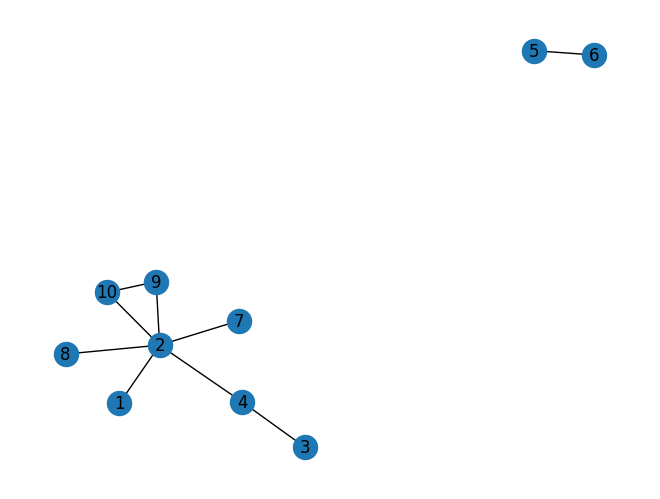

In [22]:
seed(2026)
graph0 = Graph.random_graph(10, 0.25)
graph0.plot()

In [23]:
print(graph0.connected_components())

[{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}, {1, 2, 3, 4, 7, 8, 9, 10}, {5, 6}]


In [24]:
comp = graph0.connected_components_graphs()
for g in comp:
  print(g)

1: 2
2: 1 4 7 8 9 10
3: 4
4: 2 3
7: 2
8: 2
9: 2 10
10: 2 9

5: 6
6: 5



In [26]:
print(graph0.distance(1))

{1: 0, 2: 1, 4: 2, 7: 2, 8: 2, 9: 2, 10: 2, 3: 3}


In [16]:
graph1 = Graph.random_graph(100, 0.04)
print(len(graph1.connected_components()))
print(graph1.connected_components())

6
[{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}, {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}, {13}, {43}, {58}, {88}]


### Eksperyment Millgrama (Small-world)

In [31]:
n = 2000
p = 1/500
rgraph = Graph.random_graph(n, p)
print(len(rgraph.connected_components())-1)
graph = rgraph.connected_components_graphs()[0]
print(len(graph.vertices()))

43
1958


In [32]:
md = {}
ecc = {}
for v in graph.vertices():
  dist = graph.distance(v)
  ecc[v] = max(dist.values())
  md[v] = sum(dist.values())/len(dist)
print("Promień: ", min(ecc.values()))
print("Średnica: ", max(ecc.values()))
print("Średnio: ", sum(md.values())/len(md))

Promień:  8
Średnica:  12
Średnio:  5.591610229528995


## Kody Prüfera

In [ ]:
%%writefile edges2.txt
1 3
3 5
2 5
4 5
5 6

Writing edges2.txt


In [ ]:
tree1 = Graph.from_edges('edges2.txt')
print(tree1)

1: 3
3: 1 5
5: 3 2 4 6
2: 5
4: 5
6: 5



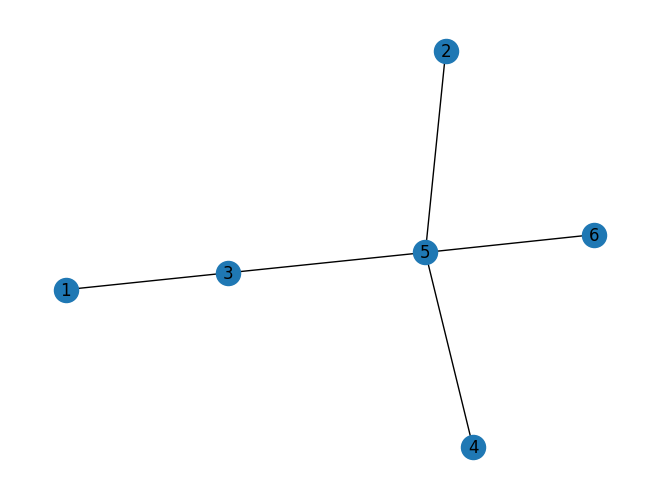

In [ ]:
tree1.plot()

In [ ]:
print(tree1.Prufer())

3 5 5 5


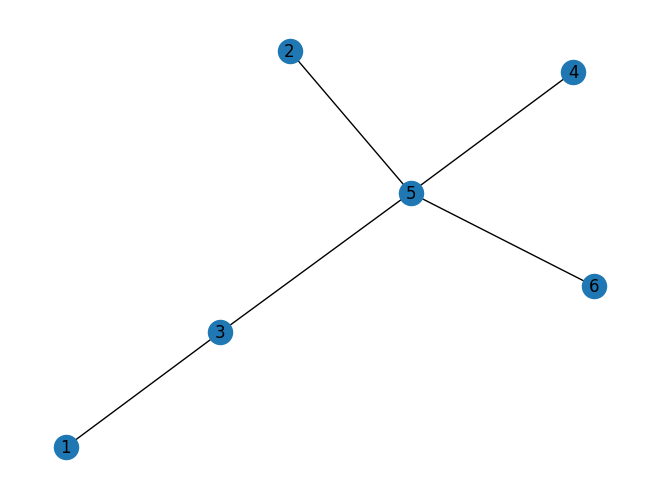

In [ ]:
tree1.plot()

In [ ]:
print(tree1)

1: 3
3: 1 5
5: 3 2 4 6
2: 5
4: 5
6: 5



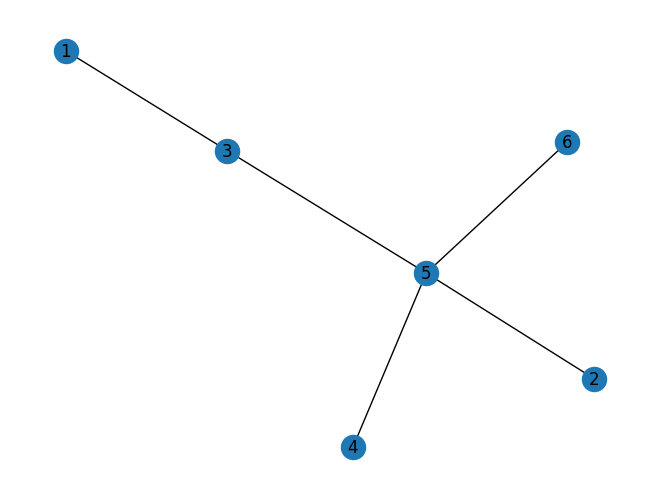

In [ ]:
Graph.tree_from_Prufer("3 5 5 5").plot()

In [ ]:
print(Graph.tree_from_Prufer("5 4 3 1"))

1: 3 6
2: 5
3: 4 1
4: 5 3
5: 2 4
6: 1



## Wczytywanie i zapis grafów

In [ ]:
%%writefile edges.txt
a b
a c
b d
c e
f

Overwriting edges.txt


In [ ]:
%cat edges.txt

a b
a c
b d
c e
f


In [ ]:
graph1 = Graph.from_edges('edges.txt')

In [ ]:
print(graph1)

a: b c
b: a d
c: a e
d: b
e: c
f:



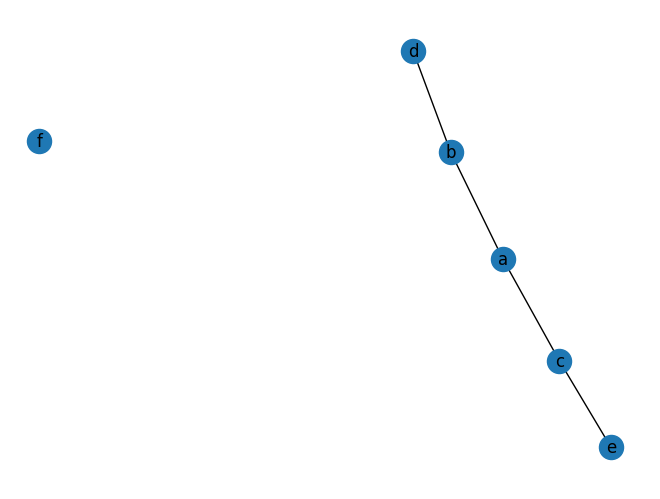

In [ ]:
graph1.plot()

In [ ]:
digraph1 = Graph.from_edges('edges.txt', directed=1)
print(digraph1)

a: b c
b: d
c: e
d:
e:
f:



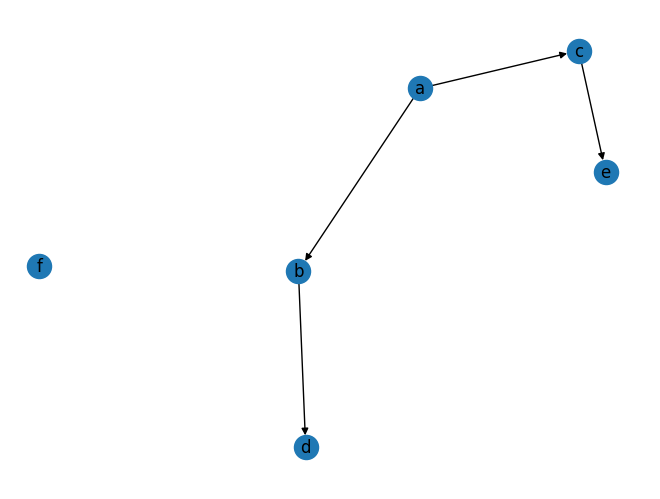

In [ ]:
digraph1.plot()

In [ ]:
!wget https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt

--2026-04-20 15:03:33--  https://raw.githubusercontent.com/pgordin/OptDisc2026/refs/heads/main/weighted0.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 114 [text/plain]
Saving to: ‘weighted0.txt’

weighted0.txt       100%[===================>]     114  --.-KB/s    in 0s      

2026-04-20 15:03:33 (1.87 MB/s) - ‘weighted0.txt’ saved [114/114]



In [ ]:
%cat weighted0.txt

A B 3
A E 10
B C 26
B D 12
C D 17
C F 13
C G 14
D E 7
D F 15
E F 8
E H 4
F G 9
F H 6
G H 16
G I 11


In [ ]:
graph2 = Graph.from_edges('weighted0.txt')
print(graph2)

A: B E
B: A C D
E: A D F H
C: B D F G
D: B C E F
F: C D E G H
G: C F H I
H: E F G
I: G



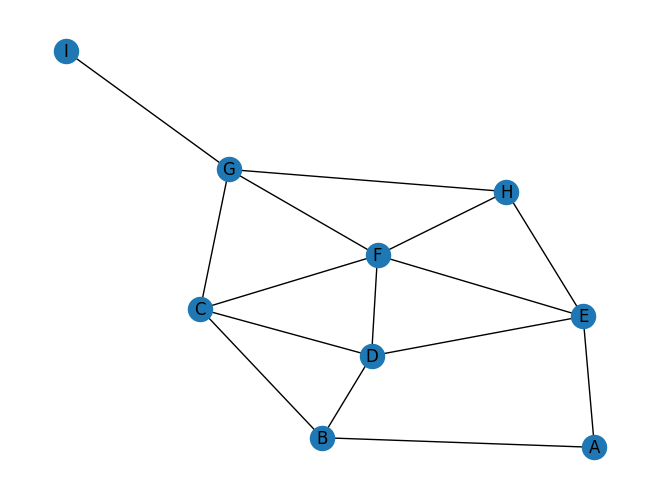

In [ ]:
graph2.plot()

In [ ]:
Graph.to_neighbourlist(graph2, 'graph2.txt')

In [ ]:
%cat graph2.txt

A: B E
B: A C D
E: A D F H
C: B D F G
D: B C E F
F: C D E G H
G: C F H I
H: E F G
I: G


In [ ]:
graph2b = Graph.from_neighbourlist('graph2.txt', directed=True)
print(graph2b)

A: B E
B: A C D
E: A D F H
C: B D F G
D: B C E F
F: C D E G H
H: E F G
G: C F H I
I: G



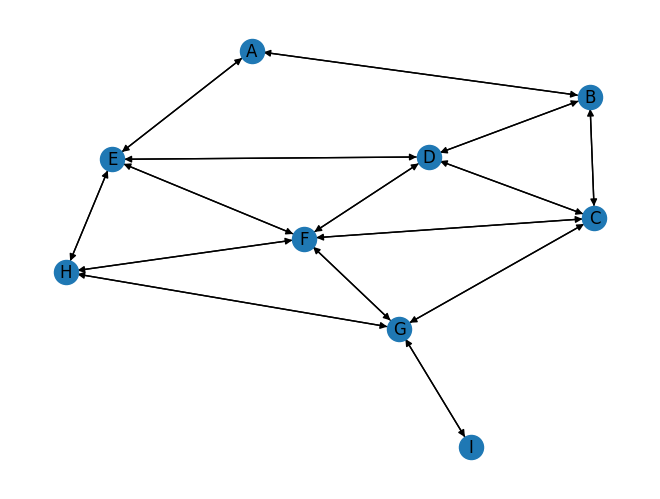

In [ ]:
graph2b.plot()

In [ ]:
seed(2026)  # dla powtarzalności
graph3 = Graph.random_graph(10, 1/3)

In [ ]:
print(graph3)

1: 2
2: 1 4 7 8 9 10
3: 4 8
4: 2 3
5: 6 9
6: 5
7: 2
8: 2 3
9: 2 5 10
10: 2 9



In [ ]:
print(Graph.cycle(6))

1: 2 6
2: 1 3
3: 2 4
4: 3 5
5: 4 6
6: 5 1



## Pierwsze zajęcia

In [ ]:
vertices = ['a', 'b', 'c', 'd']
matrix = np.array([[0,1,1,1],[1,0,0,0],[1,0,0,0],[1,0,0,0]])

In [ ]:
print(vertices)

['a', 'b', 'c', 'd']


In [ ]:
print(matrix)

[[0 1 1 1]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [ ]:
print_matrix(vertices, matrix)

a :  b  c  d
b :  a
c :  a
d :  a


In [ ]:
print_matrix(None, matrix)

1 :  2  3  4
2 :  1
3 :  1
4 :  1


In [ ]:
print_matrix(['a','b'], matrix)

1 :  2  3  4
2 :  1
3 :  1
4 :  1


In [ ]:
graph = {
    'a': ['b', 'c', 'd'],
    'b': ['a'],
    'c': ['a'],
    'd': ['a']
}

In [ ]:
print(graph)

{'a': ['b', 'c', 'd'], 'b': ['a'], 'c': ['a'], 'd': ['a']}


In [ ]:
print_dict(graph)

a :  b  c  d
b :  a
c :  a
d :  a


In [ ]:
graph0 = Graph(graph, directed=None)
print(graph0)

a: b c d f
b: a
c: a
d: a
e: f
f: a e f



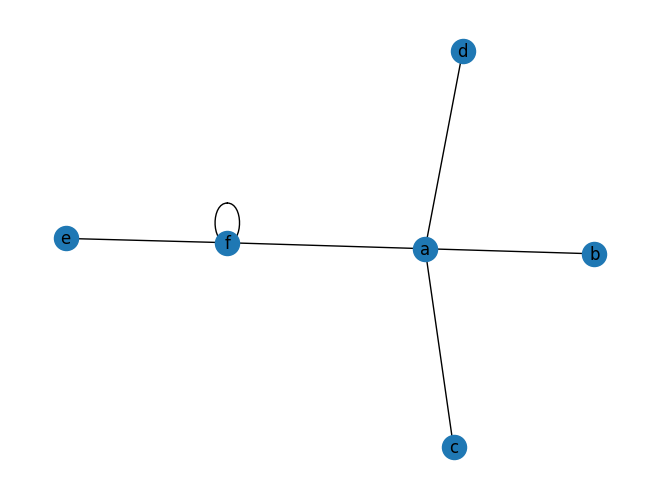

In [ ]:
graph0.plot()

In [ ]:
graph0.add_vertex('e')

In [ ]:
graph0.add_edge(('a', 'f'))

In [ ]:
print(graph0)

a: b c d f
b: a
c: a
d: a
e: f
f: a e f



In [ ]:
graph0.add_edge(('e', 'f'))

In [ ]:
graph0.add_edge(('f', 'f'))

ValueError: Pętle nie są dopuszczalne!

In [ ]:
graph0.add_arc(('f', 'f'))

In [ ]:
print(graph0)

a: b c d f
b: a
c: a
d: a
e: f
f: a e f



In [ ]:
print(graph0.matrix())

TypeError: Graph._dict_to_matrix() takes 1 positional argument but 2 were given